## 🔁 Training Logic

- **Episodes**: 5000  
- **Replay Memory**: Experience Replay (`size = 2000`)  
- **Batch Size**: 64  
- **Exploration (ε-greedy)**
  - Decay rate = 0.995  
  - Minimum ε = 0.1  
- **Optimizer**: Adam (`lr = 0.01`)  
- **Loss Function**: MSE Loss between predicted Q-values and TD targets  

---

## 🎯 Reward Design and Goal

The agent must:

1. Visit **every cell exactly once**  
2. Return to the starting cell to form a **Hamiltonian cycle**

### Reward Breakdown:

| Situation                      | Reward                          |
|-------------------------------|----------------------------------|
| Full grid visited + return to start | `+10000`                    |
| Valid move to unvisited cell       | `+100`                       |
| Revisit or wall collision          | `-1000`                      |

---


## 🖼️ Visualization

- **Pygame GUI**: Renders the grid world during gameplay  
- **Matplotlib Arrows**: Plots final best path using directional arrows  
  - 🟢 = Start  
  - 🔴 = End  
  - 🔵 = Movement arrows  

---

## ⚙️ Hyperparameters Summary

| Hyperparameter       | Value        |
|----------------------|--------------|
| Grid Size            | `6 × 6`      |
| Episodes             | `5000`       |
| Learning Rate        | `0.01`       |
| Gamma (γ)            | `0.9`        |
| Epsilon Range        | `100 → 0.1`  |
| Epsilon Decay        | `0.995`      |
| Replay Buffer Size   | `2000`       |
| Batch Size           | `64`         |
| Optimizer            | Adam         |
| Save Frequency       | Every 100 episodes |

---

## 📌 Notes

- Able to cover area but unable to form a cycle

---

Using device: cuda
Training from scratch.
Model saved to trial15.pth
Episode 1: Reward = -1000, Unique Cells = 1
Episode 2: Reward = -1000, Unique Cells = 1
Episode 3: Reward = -1000, Unique Cells = 1
Episode 4: Reward = -900, Unique Cells = 2
Episode 5: Reward = -800, Unique Cells = 3
Episode 6: Reward = -1000, Unique Cells = 1
Episode 7: Reward = -900, Unique Cells = 2
Episode 8: Reward = -300, Unique Cells = 8
Episode 9: Reward = -1000, Unique Cells = 1
Episode 10: Reward = -600, Unique Cells = 5
Episode 11: Reward = -900, Unique Cells = 2
Episode 12: Reward = -900, Unique Cells = 2
Episode 13: Reward = -900, Unique Cells = 2
Episode 14: Reward = -800, Unique Cells = 3
Episode 15: Reward = -800, Unique Cells = 3
Episode 16: Reward = -1000, Unique Cells = 1
Episode 17: Reward = -900, Unique Cells = 2
Episode 18: Reward = -1000, Unique Cells = 1
Episode 19: Reward = -900, Unique Cells = 2
Episode 20: Reward = -1000, Unique Cells = 1
Episode 21: Reward = -800, Unique Cells = 3
Episode 

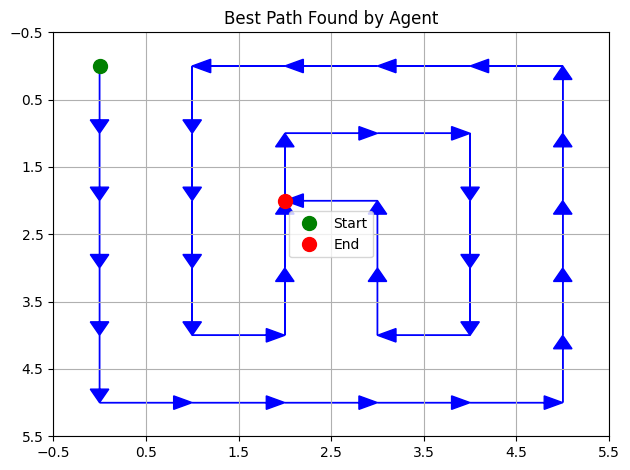

In [11]:
import os
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

# Headless mode for Jupyter + disable pygame audio
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
pygame.display.init()
pygame.font.init()

# Parameters (modify this in Jupyter to change grid size)
GRID_SIZE = 6  # Change to 4 or 6 for transfer learning
BASE_MODEL_PATH = "trial15.pth"

# Constants
WIDTH, HEIGHT = 600, 600
CELL_SIZE = WIDTH // GRID_SIZE
FPS = 60
BLACK, WHITE, RED, GREEN, BLUE = (0,0,0), (255,255,255), (255,0,0), (0,255,0), (0,0,255)

screen = pygame.Surface((WIDTH, HEIGHT))  # Dummy surface
clock = pygame.time.Clock()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DQNCNN(nn.Module):
    def __init__(self, grid_size, output_dim):
        super(DQNCNN, self).__init__()
        self.grid_size = grid_size
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * grid_size * grid_size, 256)
        self.fc2 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, self.grid_size, self.grid_size)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, grid_size, action_dim, base_model_path):
        self.grid_size = grid_size
        self.action_dim = action_dim
        self.epsilon = 1
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.1
        self.gamma = 0.9
        self.lr = 0.01
        self.batch_size = 64
        self.memory = deque(maxlen=2000)
        self.model = DQNCNN(grid_size, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Load or transfer
        if os.path.exists(base_model_path):
            print(f"Transferring weights from {base_model_path}...")
            pretrained_dict = torch.load(base_model_path, map_location=device, weights_only=True)
            model_dict = self.model.state_dict()
            transfer_dict = {k: v for k, v in pretrained_dict.items()
                             if k in model_dict and v.size() == model_dict[k].size()}
            model_dict.update(transfer_dict)
            self.model.load_state_dict(model_dict)
        else:
            print("Training from scratch.")

        self.model.train()

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = torch.FloatTensor([m[0] for m in minibatch]).to(device)
        actions = torch.LongTensor([m[1] for m in minibatch]).to(device)
        rewards = torch.FloatTensor([m[2] for m in minibatch]).to(device)
        next_states = torch.FloatTensor([m[3] for m in minibatch]).to(device)
        dones = torch.BoolTensor([m[4] for m in minibatch]).to(device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (~dones) * self.gamma * next_q

        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

def reset_game():
    grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    x, y = 0, 0
    grid[y][x] = 3
    return grid, x, y

def draw_grid(grid):
    screen.fill(BLACK)
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = grid[y][x]
            color = WHITE if val == 0 else GREEN if val == 1 else RED if val == 2 else BLUE
            pygame.draw.rect(screen, color, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE), 1)

def visualize_best_path_arrows(best_path):
    x, y = 0, 0
    path_coords = [(x, y)]
    for action in best_path:
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = x + dx, y + dy
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            x, y = new_x, new_y
            path_coords.append((x, y))
        else:
            break
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True)
    ax.invert_yaxis()
    for i in range(len(path_coords) - 1):
        x0, y0 = path_coords[i]
        x1, y1 = path_coords[i + 1]
        dx, dy = x1 - x0, y1 - y0
        ax.arrow(x0, y0, dx * 0.8, dy * 0.8, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
    ax.plot(path_coords[0][0], path_coords[0][1], 'go', markersize=10, label='Start')
    ax.plot(path_coords[-1][0], path_coords[-1][1], 'ro', markersize=10, label='End')
    ax.legend()
    plt.title("Best Path Found by Agent")
    plt.tight_layout()
    plt.show()

# === TRAINING ===
agent = DQNAgent(GRID_SIZE, 4, BASE_MODEL_PATH)
best_path = []
max_reward = 0

for episode in range(5000):  # You can increase this
    grid, player_x, player_y = reset_game()
    grid[player_y][player_x] = 2
    visited = set()
    visited.add((player_x, player_y))
    done = False
    total_reward = 0
    path = []

    while not done:
        state = np.array(grid, dtype=np.float32)
        action = agent.act(state)
        path.append(action)
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = player_x + dx, player_y + dy
        if grid[player_y][player_x] == 2:
            grid[player_y][player_x] = 1
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            if grid[new_y][new_x] in [1, 2]:
                reward = -1000
                done = True
            else:
                player_x, player_y = new_x, new_y
                grid[player_y][player_x] = 2
                visited.add((player_x, player_y))
                reward = 100
        else:
            reward = -1000
            done = True
        next_state = np.array(grid, dtype=np.float32)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        total_reward += reward
        draw_grid(grid)
        clock.tick(FPS)

    if episode%100 == 0:
        agent.save(BASE_MODEL_PATH)
    if  total_reward > max_reward:
        max_reward = total_reward
        best_path = path[:]
        print(f"total : {total_reward} max_reward : {max_reward}")
        

    print(f"Episode {episode + 1}: Reward = {total_reward}, Unique Cells = {len(visited)}")

# Visualize best
visualize_best_path_arrows(best_path)


# ✅ Testing on 4×4 Grid First

To validate the core Reinforcement Learning logic and ensure stability, we will first **test the agent on a 4×4 grid** before scaling up.

---

## 🔍 Why Start Small?

- Simplifies debugging and tuning reward functions  
- Reduces training time and computational cost  
- Helps verify correctness of movement, rewards, and transitions 

---

## 🧠 Objective

- Train the agent to **visit all 16 cells exactly once** and **return to the starting point**  
- Ensure convergence with current network architecture and hyperparameters  
- Visualize learned policies to confirm Hamiltonian behavior

---

## 📈 Outcome

A successful run on the 4×4 grid will confirm that:

- The reward structure encourages full grid coverage  

---


Using device: cuda
Training from scratch.
Model saved to trial16.pth
Episode 1: Reward = -500, Unique Cells = 6
Episode 2: Reward = -900, Unique Cells = 2
Episode 3: Reward = -1000, Unique Cells = 1
Episode 4: Reward = -1000, Unique Cells = 1
Episode 5: Reward = -700, Unique Cells = 4
Episode 6: Reward = -600, Unique Cells = 5
Episode 7: Reward = -900, Unique Cells = 2
Episode 8: Reward = -700, Unique Cells = 4
Episode 9: Reward = -900, Unique Cells = 2
Episode 10: Reward = -600, Unique Cells = 5
Episode 11: Reward = -1000, Unique Cells = 1
Episode 12: Reward = -700, Unique Cells = 4
Episode 13: Reward = -800, Unique Cells = 3
Episode 14: Reward = -800, Unique Cells = 3
Episode 15: Reward = -900, Unique Cells = 2
Episode 16: Reward = -900, Unique Cells = 2
Episode 17: Reward = -1000, Unique Cells = 1
Episode 18: Reward = -500, Unique Cells = 6
Episode 19: Reward = -1000, Unique Cells = 1
Episode 20: Reward = -1000, Unique Cells = 1
Episode 21: Reward = -1000, Unique Cells = 1
Episode 2

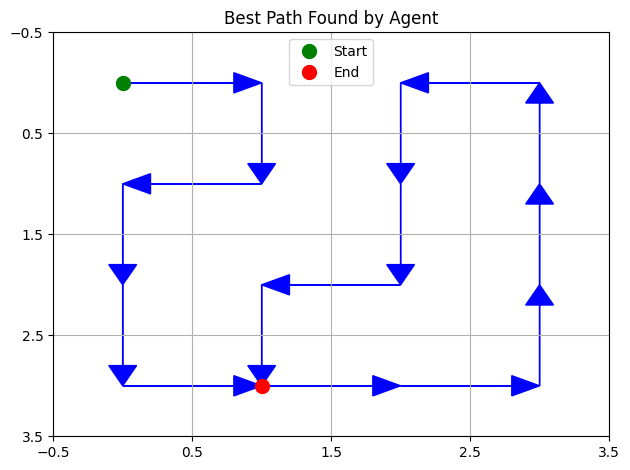

In [12]:
import os
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

# Headless mode for Jupyter + disable pygame audio
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
pygame.display.init()
pygame.font.init()

# Parameters (modify this in Jupyter to change grid size)
GRID_SIZE = 4  # Change to 4 or 6 for transfer learning
BASE_MODEL_PATH = "trial16.pth"

# Constants
WIDTH, HEIGHT = 600, 600
CELL_SIZE = WIDTH // GRID_SIZE
FPS = 60
BLACK, WHITE, RED, GREEN, BLUE = (0,0,0), (255,255,255), (255,0,0), (0,255,0), (0,0,255)

screen = pygame.Surface((WIDTH, HEIGHT))  # Dummy surface
clock = pygame.time.Clock()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DQNCNN(nn.Module):
    def __init__(self, grid_size, output_dim):
        super(DQNCNN, self).__init__()
        self.grid_size = grid_size
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * grid_size * grid_size, 256)
        self.fc2 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, self.grid_size, self.grid_size)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, grid_size, action_dim, base_model_path):
        self.grid_size = grid_size
        self.action_dim = action_dim
        self.epsilon = 1
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.1
        self.gamma = 0.9
        self.lr = 0.01
        self.batch_size = 64
        self.memory = deque(maxlen=2000)
        self.model = DQNCNN(grid_size, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Load or transfer
        if os.path.exists(base_model_path):
            print(f"Transferring weights from {base_model_path}...")
            pretrained_dict = torch.load(base_model_path, map_location=device, weights_only=True)
            model_dict = self.model.state_dict()
            transfer_dict = {k: v for k, v in pretrained_dict.items()
                             if k in model_dict and v.size() == model_dict[k].size()}
            model_dict.update(transfer_dict)
            self.model.load_state_dict(model_dict)
        else:
            print("Training from scratch.")

        self.model.train()

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = torch.FloatTensor([m[0] for m in minibatch]).to(device)
        actions = torch.LongTensor([m[1] for m in minibatch]).to(device)
        rewards = torch.FloatTensor([m[2] for m in minibatch]).to(device)
        next_states = torch.FloatTensor([m[3] for m in minibatch]).to(device)
        dones = torch.BoolTensor([m[4] for m in minibatch]).to(device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (~dones) * self.gamma * next_q

        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

def reset_game():
    grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    x, y = 0, 0
    grid[y][x] = 3
    return grid, x, y

def draw_grid(grid):
    screen.fill(BLACK)
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = grid[y][x]
            color = WHITE if val == 0 else GREEN if val == 1 else RED if val == 2 else BLUE
            pygame.draw.rect(screen, color, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE), 1)

def visualize_best_path_arrows(best_path):
    x, y = 0, 0
    path_coords = [(x, y)]
    for action in best_path:
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = x + dx, y + dy
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            x, y = new_x, new_y
            path_coords.append((x, y))
        else:
            break
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True)
    ax.invert_yaxis()
    for i in range(len(path_coords) - 1):
        x0, y0 = path_coords[i]
        x1, y1 = path_coords[i + 1]
        dx, dy = x1 - x0, y1 - y0
        ax.arrow(x0, y0, dx * 0.8, dy * 0.8, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
    ax.plot(path_coords[0][0], path_coords[0][1], 'go', markersize=10, label='Start')
    ax.plot(path_coords[-1][0], path_coords[-1][1], 'ro', markersize=10, label='End')
    ax.legend()
    plt.title("Best Path Found by Agent")
    plt.tight_layout()
    plt.show()

# === TRAINING ===
agent = DQNAgent(GRID_SIZE, 4, BASE_MODEL_PATH)
best_path = []
max_reward = 0

for episode in range(5000):  # You can increase this
    grid, player_x, player_y = reset_game()
    grid[player_y][player_x] = 2
    visited = set()
    visited.add((player_x, player_y))
    done = False
    total_reward = 0
    path = []

    while not done:
        state = np.array(grid, dtype=np.float32)
        action = agent.act(state)
        path.append(action)
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = player_x + dx, player_y + dy
        if grid[player_y][player_x] == 2:
            grid[player_y][player_x] = 1
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            if grid[new_y][new_x] in [1, 2]:
                reward = -1000
                done = True
            else:
                player_x, player_y = new_x, new_y
                grid[player_y][player_x] = 2
                visited.add((player_x, player_y))
                reward = 100
        else:
            reward = -1000
            done = True
        next_state = np.array(grid, dtype=np.float32)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        total_reward += reward
        draw_grid(grid)
        clock.tick(FPS)

    if episode%100 == 0:
        agent.save(BASE_MODEL_PATH)
    if  total_reward > max_reward:
        max_reward = total_reward
        best_path = path[:]
        print(f"total : {total_reward} max_reward : {max_reward}")
        

    print(f"Episode {episode + 1}: Reward = {total_reward}, Unique Cells = {len(visited)}")

# Visualize best
visualize_best_path_arrows(best_path)


# 🔍 Observations and Proposed Curriculum Strategy

---

## 📌 Observations on 4×4 and 6×6 Grids

- In both the 4×4 and 6×6 experiments, the model was **able to cover the entire grid** effectively.
- However, it **failed to return to the starting point**, meaning it **did not form a complete Hamiltonian cycle**.
- This suggests the model is learning to **maximize coverage**, but not necessarily to **close the loop**.

---

## 🧠 Our Assumption

We hypothesize that there are **two distinct objectives** the model must learn:

1. ✅ **Complete the Grid**: Visit every cell exactly once  
2. 🔁 **Form a Cycle**: Return to the starting point after visiting all cells  

The agent appears to **focus entirely on coverage** and **neglects forming the cycle**, likely due to insufficient incentive or experience completing cycles during training.

---

## 🧪 Proposed Solution: Curriculum Learning

To help the model **gradually learn both objectives**, we propose a stepwise training strategy:

### Step 1: Start with 2×2 Grid  
- The only way to **visit all cells** in a 2×2 grid is to **form a perfect Hamiltonian cycle**  
- This forces the agent to **internalize the importance of cycling back**

### Step 2: Train on 4×4 Grid  
- With cycle formation intuition from 2×2, the agent can now apply that knowledge to **larger grids**  
- It can now begin to balance **coverage and return behavior**

### Step 3: Scale to 6×6 and Beyond  
- Fine-tune the model on increasingly larger grids (e.g., 6×6, 8×8) using **transfer learning**
- Encourage generalization of Hamiltonian cycle formation

---

## 🎯 Expected Outcome

This curriculum-based approach aims to teach the model to **first learn cycle formation** in a minimal environment, and then **scale the behavior** to more complex grids, eventually solving the Hamiltonian Cycle problem effectively.

---
